In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE

fraud = pd.read_csv("../data/raw/Fraud_Data.csv")
ip_country = pd.read_csv("../data/raw/IpAddress_to_Country.csv")
credit = pd.read_csv("../data/raw/creditcard.csv")

print(fraud.shape)
print(ip_country.shape)
print(credit.shape)

(151112, 11)
(138846, 3)
(284807, 31)


In [3]:
print(fraud.info())
print(credit.info())

print(fraud.isnull().sum())
print(credit.isnull().sum())

print("Fraud duplicates:", fraud.duplicated().sum())
print("Credit duplicates:", credit.duplicated().sum())

fraud = fraud.drop_duplicates()
credit = credit.drop_duplicates()

fraud["signup_time"] = pd.to_datetime(fraud["signup_time"])
fraud["purchase_time"] = pd.to_datetime(fraud["purchase_time"])
fraud["ip_address"] = fraud["ip_address"].astype(int)

credit["Class"] = credit["Class"].astype(int)

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-

Missing values were checked in both datasets. No missing values were found, so no imputation was required. Duplicates were removed to avoid repeated transactions biasing the analysis. Timestamp columns in Fraud_Data were converted to datetime format, and class columns were kept as integers.

In [5]:
print("Fraud_Data class distribution")
print(fraud["class"].value_counts())
print(fraud["class"].value_counts(normalize=True) * 100)

print("Creditcard class distribution")
print(credit["Class"].value_counts())
print(credit["Class"].value_counts(normalize=True) * 100)

Fraud_Data class distribution
class
0    136961
1     14151
Name: count, dtype: int64
class
0    90.635423
1     9.364577
Name: proportion, dtype: float64
Creditcard class distribution
Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


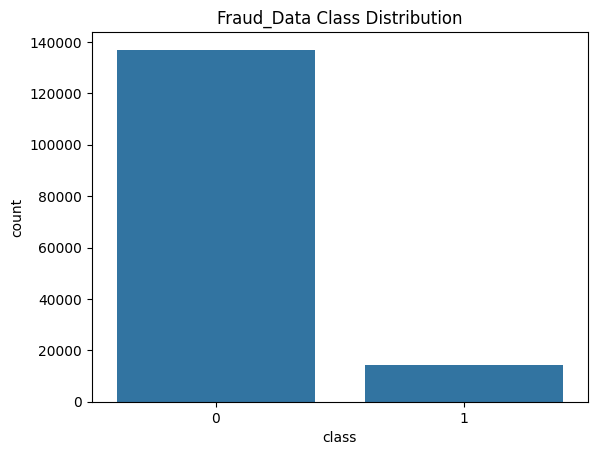

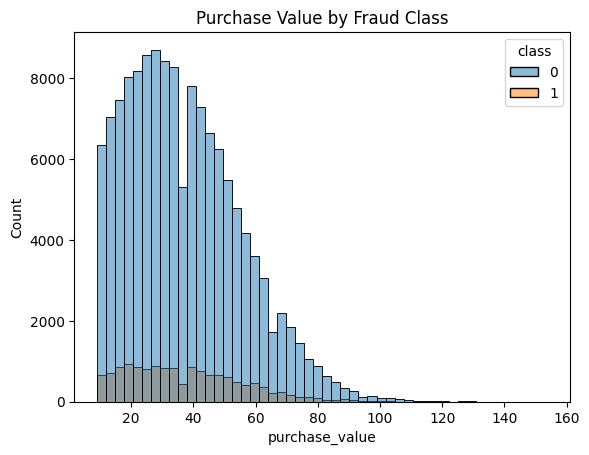

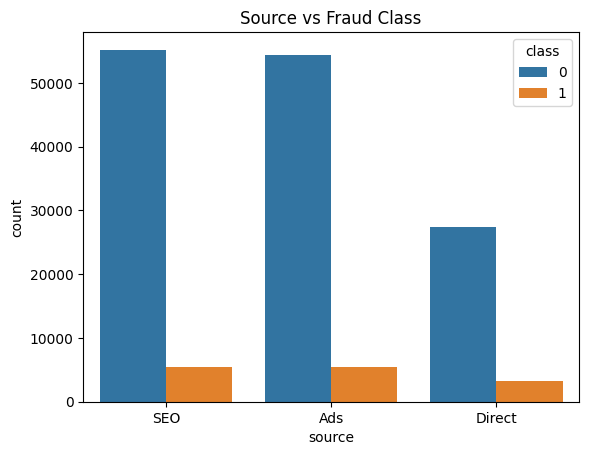

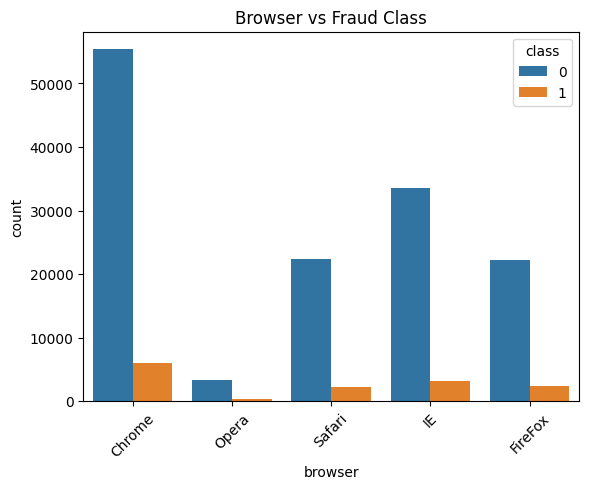

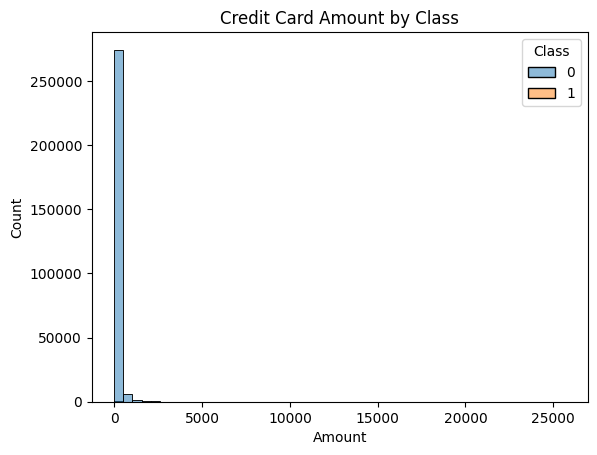

In [6]:
sns.countplot(data=fraud, x="class")
plt.title("Fraud_Data Class Distribution")
plt.show()

sns.histplot(data=fraud, x="purchase_value", hue="class", bins=50)
plt.title("Purchase Value by Fraud Class")
plt.show()

sns.countplot(data=fraud, x="source", hue="class")
plt.title("Source vs Fraud Class")
plt.show()

sns.countplot(data=fraud, x="browser", hue="class")
plt.title("Browser vs Fraud Class")
plt.xticks(rotation=45)
plt.show()

sns.histplot(data=credit, x="Amount", hue="Class", bins=50)
plt.title("Credit Card Amount by Class")
plt.show()